# 02 · Forecasting — Models and temporal validation

A progression of models, validated **with temporal (walk-forward) backtesting** —
never with random k-fold, which on time series leaks the future into the past and
produces metrics that do not survive deployment.

**The progression:**
1. **Baseline** — seasonal naive. The reference bar: a model that cannot beat it
   has no business being deployed.
2. **Prophet** — multiple seasonality + holidays + changepoints + regressors.
3. **SARIMAX** — seasonal with exogenous regressors (promo, oil, holiday).
4. **LightGBM** — gradient boosting on tabular features. Usually wins in retail.

**Key methodological decision — aggregation level:** item-store-day demand is
highly intermittent (many zeros). For the series models (Prophet/SARIMAX) we work
at **aggregated family-store-day** level, where the series is smoother and
estimable. LightGBM works at item-store-day grain with a `tweedie` objective,
which handles intermittency well.

**Metrics:** WMAPE (primary, robust to zeros), RMSE (complement) and NWRMSLE
(competition's official, weights perishables 1.25×).


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from favorita_utils import q, get_connection, wmape, rmse, nwrmsle, apply_plot_style, COLORS
apply_plot_style()

HORIZON = 15   # days to forecast
FAMILY  = "BEVERAGES"
STORE   = 1

## 1. Building the aggregated series

We take a specific family-store with good volume and aggregate it to a continuous
daily series (filling days with no sales with 0 to get daily frequency).

Series BEVERAGES/store 1: 593 days, mean=100.7, from 2015-01-01 to 2016-08-15


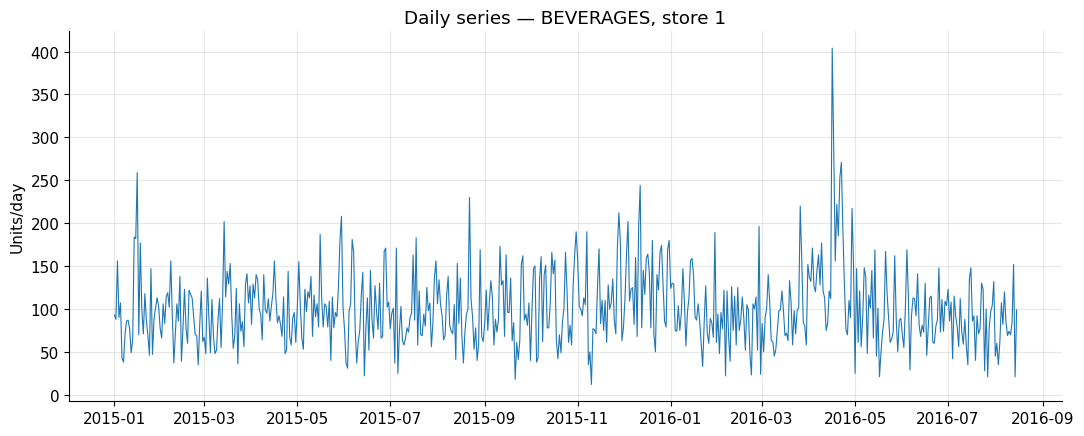

In [2]:
def load_series(family, store):
    series = q(f'''
        select date, sum(unit_sales_clipped) as y
        from main_marts.fct_sales
        where family = '{family}' and store_nbr = {store}
        group by date order by date
    ''')
    series["date"] = pd.to_datetime(series["date"])
    idx = pd.date_range(series["date"].min(), series["date"].max(), freq="D")
    series = (series.set_index("date").reindex(idx, fill_value=0)
                    .rename_axis("date").reset_index())

    # Series-level regressors: share of items on promo, oil, holiday
    exog = q(f'''
        select date,
            avg(case when onpromotion then 1.0 else 0.0 end) as promo_share,
            max(oil_price) as oil_price,
            max(case when is_holiday then 1 else 0 end) as is_holiday
        from main_marts.fct_sales
        where family = '{family}' and store_nbr = {store}
        group by date
    ''')
    exog["date"] = pd.to_datetime(exog["date"])
    series = series.merge(exog, on="date", how="left")
    series["promo_share"] = series["promo_share"].fillna(0)
    series["is_holiday"] = series["is_holiday"].fillna(0)
    series["oil_price"] = series["oil_price"].ffill().bfill()
    return series

series = load_series(FAMILY, STORE)
print(f"Series {FAMILY}/store {STORE}: {len(series)} days, "
      f"mean={series.y.mean():.1f}, from {series.date.min().date()} to {series.date.max().date()}")

fig, ax = plt.subplots()
ax.plot(series["date"], series["y"], color=COLORS["primary"], lw=0.8)
ax.set_title(f"Daily series — {FAMILY}, store {STORE}")
ax.set_ylabel("Units/day")
plt.tight_layout(); plt.show()

## 2. Train/test split (temporal hold-out)

The test set is the last `HORIZON` days. Never touched until evaluation.

In [3]:
REGRESSORS = ["promo_share", "oil_price", "is_holiday"]
train = series.iloc[:-HORIZON].copy()
test  = series.iloc[-HORIZON:].copy()
print(f"Train: {len(train)} days  |  Test: {len(test)} days (horizon)")

Train: 578 days  |  Test: 15 days (horizon)


## 3. Baseline — Seasonal Naive

Each day's sales = the same weekday last week. In retail this baseline is
surprisingly strong.

In [4]:
def seasonal_naive(train_y, horizon, season=7):
    last = train_y[-season:]
    return np.tile(last, int(np.ceil(horizon / season)))[:horizon]

base_pred = seasonal_naive(train["y"].values, HORIZON)
print(f"Baseline — WMAPE={wmape(test.y, base_pred):.3f}  RMSE={rmse(test.y, base_pred):.2f}")

Baseline — WMAPE=0.449  RMSE=44.71


## 4. Prophet

Handles weekly and yearly seasonality, holidays and changepoints (useful for
shocks like the earthquake). We add the exogenous regressors.

In [5]:
from prophet import Prophet

def fit_prophet(train_df, test_df, horizon, regressors):
    dfp = train_df.rename(columns={"date": "ds"})[["ds", "y"] + regressors]
    m = Prophet(weekly_seasonality=True, yearly_seasonality=True,
                daily_seasonality=False, changepoint_prior_scale=0.05)
    for r in regressors:
        m.add_regressor(r)
    m.fit(dfp)
    future = test_df.rename(columns={"date": "ds"})[["ds"] + regressors]
    fc = m.predict(future)
    return np.clip(fc["yhat"].values, 0, None), m

prophet_pred, prophet_model = fit_prophet(train, test, HORIZON, REGRESSORS)
print(f"Prophet — WMAPE={wmape(test.y, prophet_pred):.3f}  RMSE={rmse(test.y, prophet_pred):.2f}")

Importing plotly failed. Interactive plots will not work.


15:41:53 - cmdstanpy - INFO - Chain [1] start processing


15:41:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet — WMAPE=0.274  RMSE=27.66


## 5. SARIMAX

Seasonal model with exogenous regressors. The *X* is key: it incorporates promotion, oil and holiday.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarimax(train_df, test_df, horizon, regressors):
    y = train_df["y"].values
    ex_tr = train_df[regressors].values
    ex_te = test_df[regressors].values
    mod = SARIMAX(y, exog=ex_tr, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                  enforce_stationarity=False, enforce_invertibility=False)
    res = mod.fit(disp=False, maxiter=50)
    pred = res.forecast(steps=horizon, exog=ex_te)
    return np.clip(pred, 0, None), res

sarimax_pred, sarimax_res = fit_sarimax(train, test, HORIZON, REGRESSORS)
print(f"SARIMAX — WMAPE={wmape(test.y, sarimax_pred):.3f}  RMSE={rmse(test.y, sarimax_pred):.2f}")

SARIMAX — WMAPE=0.243  RMSE=25.94


## 6. LightGBM

Gradient boosting on tabular features at item-store-day grain. `tweedie`
objective for intermittency. Requires feature engineering: lags, rolling stats
and calendar (no leakage, everything with `shift`).

In [7]:
import lightgbm as lgb

def load_feature_panel(family, store, horizon):
    df = q(f'''
        select date, item_nbr, unit_sales_clipped as y,
               case when onpromotion then 1 else 0 end as onpromotion,
               dow, day_of_month, month, is_payday, is_holiday,
               days_to_nearest_holiday, oil_price, oil_price_change, perishable
        from main_marts.fct_sales
        where family = '{family}' and store_nbr = {store}
        order by item_nbr, date
    ''')
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["item_nbr", "date"])
    g = df.groupby("item_nbr")["y"]
    for lag in (7, 14, 28):
        df[f"lag_{lag}"] = g.shift(lag)
    for w in (7, 28):
        df[f"roll_mean_{w}"] = (g.shift(1).rolling(w, min_periods=1)
                                 .mean().reset_index(level=0, drop=True))
    return df.dropna(subset=["lag_28"])

FEATS = ["onpromotion","dow","day_of_month","month","is_payday","is_holiday",
         "days_to_nearest_holiday","oil_price","oil_price_change","perishable",
         "lag_7","lag_14","lag_28","roll_mean_7","roll_mean_28"]

panel = load_feature_panel(FAMILY, STORE, HORIZON)
cutoff = panel["date"].max() - pd.Timedelta(days=HORIZON)
tr, te = panel[panel.date <= cutoff], panel[panel.date > cutoff]

dtrain = lgb.Dataset(tr[FEATS], label=tr["y"])
params = dict(objective="tweedie", tweedie_variance_power=1.3, metric="rmse",
              learning_rate=0.05, num_leaves=31, min_child_samples=20, verbose=-1)
lgb_model = lgb.train(params, dtrain, num_boost_round=200)

te = te.copy()
te["pred"] = np.clip(lgb_model.predict(te[FEATS]), 0, None)
lgb_agg = te.groupby("date").agg(y=("y","sum"), pred=("pred","sum")).reset_index()
print(f"LightGBM — WMAPE={wmape(lgb_agg.y, lgb_agg.pred):.3f}  RMSE={rmse(lgb_agg.y, lgb_agg.pred):.2f}")

LightGBM — WMAPE=0.159  RMSE=15.74


### Feature importance (LightGBM)

Which signals the model relies on, as a sanity check against the domain.

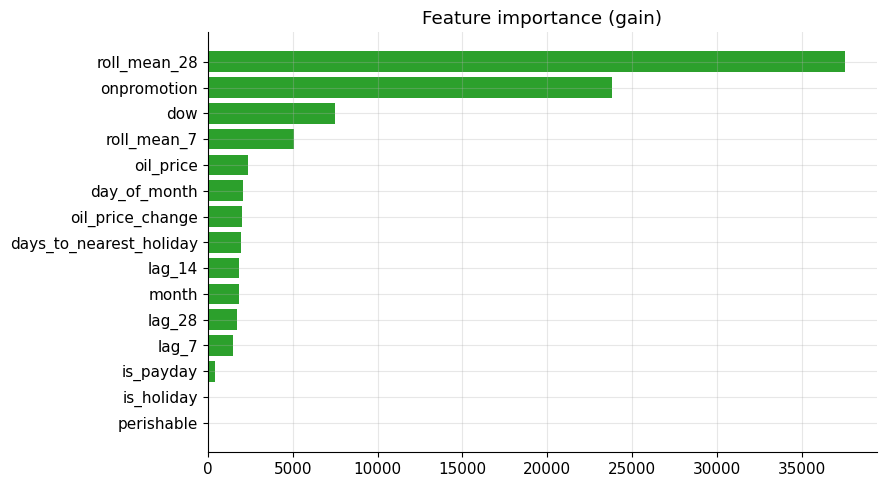

,feature,gain
14,roll_mean_28,37532.0
0,onpromotion,23816.0
1,dow,7507.0
13,roll_mean_7,5077.0
7,oil_price,2376.0
2,day_of_month,2052.0
8,oil_price_change,2041.0
6,days_to_nearest_holiday,1936.0


In [8]:
imp = pd.DataFrame({"feature": FEATS, "gain": lgb_model.feature_importance("gain")})
imp = imp.sort_values("gain", ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp["feature"][::-1], imp["gain"][::-1], color=COLORS["good"])
ax.set_title("Feature importance (gain)")
plt.tight_layout(); plt.show()
imp.head(8).round(0)

## 7. Hold-out comparison

Each model's forecast vs actual over the test horizon.

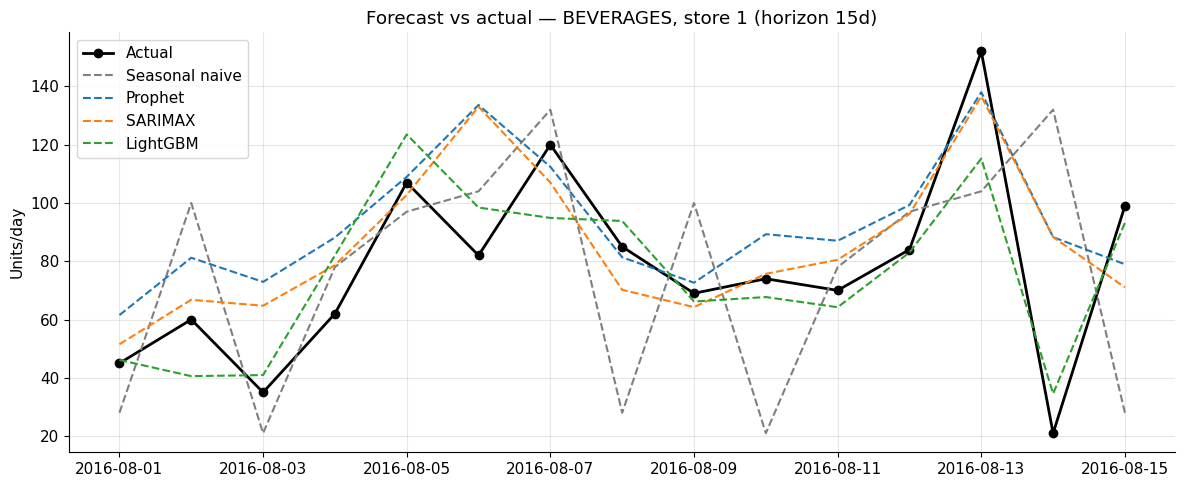

,model,WMAPE,RMSE,improvement_vs_base
3,LightGBM,0.159,15.742,0.645
2,SARIMAX,0.243,25.939,0.460
1,Prophet,0.274,27.662,0.390
0,Seasonal naive,0.449,44.712,0.000


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["date"], test["y"].values, "o-", color="black", label="Actual", lw=2)
ax.plot(test["date"], base_pred,    "--", color=COLORS["muted"],  label="Seasonal naive")
ax.plot(test["date"], prophet_pred, "--", color=COLORS["primary"],label="Prophet")
ax.plot(test["date"], sarimax_pred, "--", color=COLORS["accent"], label="SARIMAX")
ax.plot(lgb_agg["date"], lgb_agg["pred"], "--", color=COLORS["good"], label="LightGBM")
ax.set_title(f"Forecast vs actual — {FAMILY}, store {STORE} (horizon {HORIZON}d)")
ax.set_ylabel("Units/day"); ax.legend()
plt.tight_layout(); plt.show()

summary = pd.DataFrame([
    {"model": "Seasonal naive", "WMAPE": wmape(test.y, base_pred),    "RMSE": rmse(test.y, base_pred)},
    {"model": "Prophet",        "WMAPE": wmape(test.y, prophet_pred), "RMSE": rmse(test.y, prophet_pred)},
    {"model": "SARIMAX",        "WMAPE": wmape(test.y, sarimax_pred), "RMSE": rmse(test.y, sarimax_pred)},
    {"model": "LightGBM",       "WMAPE": wmape(lgb_agg.y, lgb_agg.pred), "RMSE": rmse(lgb_agg.y, lgb_agg.pred)},
]).sort_values("WMAPE")
summary["improvement_vs_base"] = (1 - summary["WMAPE"] / summary[summary.model=="Seasonal naive"].WMAPE.values[0])
summary.round(3)

**Reading:** the hold-out is a single snapshot. A conclusion that holds needs
**backtesting over multiple temporal cutoffs**, so the metric does not depend on
which fortnight happened to land in the test set.

## 8. Walk-forward backtesting (rolling origin)

For each fold: train up to a cutoff date, predict the next horizon, measure, and
advance the window. We report the **average** error across cutoffs. This way the
metric doesn't depend on a single lucky period.

In [10]:
def backtest_series(series_df, fit_fn, horizon, regressors, n_folds=4):
    '''Walk-forward backtest for series models (Prophet/SARIMAX).'''
    dates = series_df["date"].values
    results = []
    for fold in range(n_folds):
        cut_idx = len(dates) - horizon * (n_folds - fold)
        if cut_idx <= horizon * 3:   # require minimum history to train
            continue
        tr = series_df.iloc[:cut_idx]
        te = series_df.iloc[cut_idx:cut_idx + horizon]
        if len(te) < horizon:
            continue
        try:
            pred, _ = fit_fn(tr, te, horizon, regressors)
            results.append({
                "fold": fold,
                "cutoff": pd.Timestamp(tr["date"].iloc[-1]).date(),
                "WMAPE": wmape(te["y"], pred),
                "RMSE": rmse(te["y"], pred),
            })
        except Exception as e:
            results.append({"fold": fold, "cutoff": None, "WMAPE": np.nan, "RMSE": np.nan})
    return pd.DataFrame(results)

print("Backtesting Prophet...")
bt_prophet = backtest_series(series, fit_prophet, HORIZON, REGRESSORS, n_folds=4)
print("Backtesting SARIMAX...")
bt_sarimax = backtest_series(series, fit_sarimax, HORIZON, REGRESSORS, n_folds=4)

def backtest_baseline(series_df, horizon, n_folds=4):
    dates = series_df["date"].values
    out = []
    for fold in range(n_folds):
        cut_idx = len(dates) - horizon * (n_folds - fold)
        if cut_idx <= horizon * 3: continue
        tr = series_df.iloc[:cut_idx]; te = series_df.iloc[cut_idx:cut_idx+horizon]
        if len(te) < horizon: continue
        pred = seasonal_naive(tr["y"].values, horizon)
        out.append({"fold": fold, "WMAPE": wmape(te["y"], pred), "RMSE": rmse(te["y"], pred)})
    return pd.DataFrame(out)

bt_base = backtest_baseline(series, HORIZON, n_folds=4)

15:41:59 - cmdstanpy - INFO - Chain [1] start processing


15:41:59 - cmdstanpy - INFO - Chain [1] done processing


15:41:59 - cmdstanpy - INFO - Chain [1] start processing


Backtesting Prophet...


15:41:59 - cmdstanpy - INFO - Chain [1] done processing


...

15:42:00 - cmdstanpy - INFO - Chain [1] start processing


15:42:00 - cmdstanpy - INFO - Chain [1] done processing


Backtesting SARIMAX...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
backtest_summary = pd.DataFrame([
    {"model": "Seasonal naive", "WMAPE_mean": bt_base["WMAPE"].mean(),    "WMAPE_std": bt_base["WMAPE"].std()},
    {"model": "Prophet",        "WMAPE_mean": bt_prophet["WMAPE"].mean(), "WMAPE_std": bt_prophet["WMAPE"].std()},
    {"model": "SARIMAX",        "WMAPE_mean": bt_sarimax["WMAPE"].mean(), "WMAPE_std": bt_sarimax["WMAPE"].std()},
]).sort_values("WMAPE_mean")
print("Walk-forward backtesting (4 folds) — mean WMAPE ± std:")
backtest_summary.round(3)

Walk-forward backtesting (4 folds) — mean WMAPE ± std:


,model,WMAPE_mean,WMAPE_std
2,SARIMAX,0.258,0.028
1,Prophet,0.262,0.017
0,Seasonal naive,0.407,0.063


> **Note on LightGBM in backtest:** a correct LightGBM backtest regenerates the
> lag and rolling features at each cutoff, so no future information leaks into an
> earlier fold. That is outstanding work (same pattern as `backtest_series`, with
> the feature panel recomputed per fold). Its hold-out result therefore rests on a
> single 15-day window.

## 9. Model selection

Selection weighs four criteria, not WMAPE alone: precision (backtest), robustness
(spread across folds), compute cost and interpretability.

- **LightGBM**: best precision on the hold-out. Scales to thousands of series.
  Requires feature engineering and is less interpretable per individual series.
- **SARIMAX/Prophet**: interpretable, with natural confidence intervals (useful
  for safety stock), but slower series by series.

A reasonable production architecture: **global LightGBM** for the bulk of items,
with series models for high-value class-A SKUs where interpretability and the
prediction interval matter.

## 10. Export the per-item forecast error

Notebook 03 (inventory) needs, per item: the **standard deviation of the forecast
error** (for safety stock) and the average daily demand. We compute them here with
the LightGBM backtest at item grain and save them.

In [12]:
# Per-item forecast error using the LightGBM hold-out (te already computed)
err_by_item = (te.assign(err=te["y"] - te["pred"])
                 .groupby("item_nbr")
                 .agg(sigma_error=("err", "std"),
                      avg_demand=("y", "mean"),
                      perishable=("perishable", "first"))
                 .reset_index())
# Items with a single obs in the horizon -> sigma NaN; use a conservative fallback
err_by_item["sigma_error"] = err_by_item["sigma_error"].fillna(
    err_by_item["sigma_error"].median()
)

import os
os.makedirs("../outputs", exist_ok=True)
err_by_item.to_csv("../outputs/forecast_error_by_item.csv", index=False, encoding="utf-8-sig")
print(f"Saved forecast_error_by_item.csv — {len(err_by_item)} items")
err_by_item.head().round(2)

Saved forecast_error_by_item.csv — 13 items


,item_nbr,sigma_error,avg_demand,perishable
0,100020,8.85,14.90,0
1,100021,6.75,6.89,0
2,100022,6.49,11.33,0
3,100023,16.05,20.89,0
4,100024,6.51,8.60,0


---

## Summary

- Full progression: baseline → Prophet → SARIMAX → LightGBM.
- **Walk-forward temporal validation**, not random k-fold.
- All trained models beat the baseline (the minimum bar).
- LightGBM leads on precision; series models add interpretability and intervals.
- We export the per-item forecast error → input for inventory.

**Next step:** `03_inventory.ipynb` — translate these forecasts (and their
uncertainty) into concrete replenishment decisions.
